# Задача 2. Мультиклассовая классификация нормативно-правовых актов по коду документа

В работе решается задача классификации текстов нормативно-правовых актов по коду документа.  
Датасет содержит текст документа и целевой код. Код рассматривается как иерархическая целевая переменная: полный код и несколько укрупненных уровней. Для итогового обучения используется полный код `target_full`, так как после проверки он дает 58 классов и не требует сильного укрупнения.

Основной подход: TF-IDF-векторизация текста и линейные модели классификации. Дополнительно проводится анализ признаков на возможные утечки: проверяются даты, номера документов, годы, технические коды, административные маркеры и прямое присутствие целевого кода в тексте.


## 1. Импорты и настройки

In [1]:
from pathlib import Path
import re
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)
from sklearn.exceptions import ConvergenceWarning
import joblib

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Файл должен лежать в одной папке с ноутбуком.
DATA_PATH = Path("Для задачи 2_ internship_50k.parquet")

# В датасете уже известны рабочие колонки, поэтому автоопределение не используется.
TEXT_COL = "text"
TARGET_COL = "code"

# Для итоговой модели используется полный код документа.
TARGET_LEVEL = "target_full"

# Фильтрация классов, чтобы stratified split был корректным.
MIN_SAMPLES_PER_CLASS = 2

# Параметры TF-IDF.
WORD_MAX_FEATURES = 180_000
CHAR_MAX_FEATURES = 160_000
WORD_NGRAM_RANGE = (1, 2)
CHAR_NGRAM_RANGE = (3, 5)
MIN_DF = 2
MAX_DF = 0.95

TOP_N_FEATURES_TO_SAVE = 500
TOP_N_CLASSES_FOR_PLOTS = 25
TOP_N_ERROR_EXAMPLES = 50

OUTPUT_DIR = Path("task2_outputs_final")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

print(f"Папка для результатов: {OUTPUT_DIR.resolve()}")


Папка для результатов: D:\Документы\учеба\ТЗ правительство москвы\task2_outputs_final


## 2. Загрузка данных

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Файл {DATA_PATH} не найден. Проверьте, что parquet-файл лежит в одной папке с ноутбуком "
        "и что имя файла указано правильно в переменной DATA_PATH."
    )

df = pd.read_parquet(DATA_PATH)

print(f"Размер датасета: {df.shape[0]:,} строк, {df.shape[1]:,} столбцов")
display(df.head(3))

required_cols = {TEXT_COL, TARGET_COL}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"В датасете не найдены обязательные колонки: {missing_cols}")

print(f"Текстовая колонка: {TEXT_COL}")
print(f"Целевая колонка: {TARGET_COL}")


Размер датасета: 50,002 строк, 2 столбцов


,code,text
0,010.160.030,ПОСТАНОВЛЕНИЕ от 12.02.2025 № 53 Администрация Обливского района 22.01.2026 Текст документа ﻿ ПОСТАНОВЛЕНИЕ РОССИЙСКАЯ ФЕДЕРАЦИЯ РОСТОВСКАЯ ОБЛАСТЬ МУНИЦИПАЛЬНОЕ ОБРАЗОВАНИЕ «О...
1,010.150.000,ПОСТАНОВЛЕНИЕ от 27.10.2025 № 1271 АДМИНИСТРАЦИЯ НИКОЛЬСКОГО МУНИЦИПАЛЬНОГО ОКРУГА 21.01.2026 Текст документа ﻿ АДМИНИСТРАЦИЯ НИКОЛ Ь СКОГО МУНИЦИПАЛЬНОГО ОКРУГА ПОСТАНОВЛЕНИЕ ...
2,020.000.000,ПОСТАНОВЛЕНИЕ от 20.03.2025 № 17 Администрация Краснянского сельского поселения Новохоперского муниципального района Воронежской области 23.01.2026 Текст документа ﻿ АДМИНИСТРА...


Текстовая колонка: text
Целевая колонка: code


## 3. Первичный анализ данных

На этом этапе проверяются типы колонок, пропуски, число уникальных значений, длина текстов и дубликаты. Это нужно, чтобы убедиться, что текстовая и целевая колонки пригодны для обучения модели.


In [3]:
eda_rows = []
for col in df.columns:
    s = df[col]
    row = {
        "column": col,
        "dtype": str(s.dtype),
        "missing": int(s.isna().sum()),
        "missing_share": float(s.isna().mean()),
        "n_unique": int(s.nunique(dropna=True)),
    }
    if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
        sample = s.dropna().astype(str)
        if len(sample) > 5000:
            sample = sample.sample(5000, random_state=RANDOM_STATE)
        row["avg_len_sample"] = float(sample.str.len().mean()) if len(sample) else 0.0
        row["median_len_sample"] = float(sample.str.len().median()) if len(sample) else 0.0
        row["max_len_sample"] = int(sample.str.len().max()) if len(sample) else 0
    else:
        row["avg_len_sample"] = np.nan
        row["median_len_sample"] = np.nan
        row["max_len_sample"] = np.nan
    eda_rows.append(row)

eda_df = pd.DataFrame(eda_rows)
display(eda_df)
eda_df.to_csv(OUTPUT_DIR / "eda_columns_info.csv", index=False, encoding="utf-8-sig")

print(f"Полных дубликатов строк: {df.duplicated().sum():,}")


,column,dtype,missing,missing_share,n_unique,avg_len_sample,median_len_sample,max_len_sample
0,code,string,0,0.0,58,11.0000,11.0,11
1,text,string,0,0.0,49997,29735.4898,8392.5,1230843


Полных дубликатов строк: 5


Длина текстов:
Средняя длина: 28261.1
Медианная длина: 7991.0
Минимальная длина: 66
Максимальная длина: 6,974,726


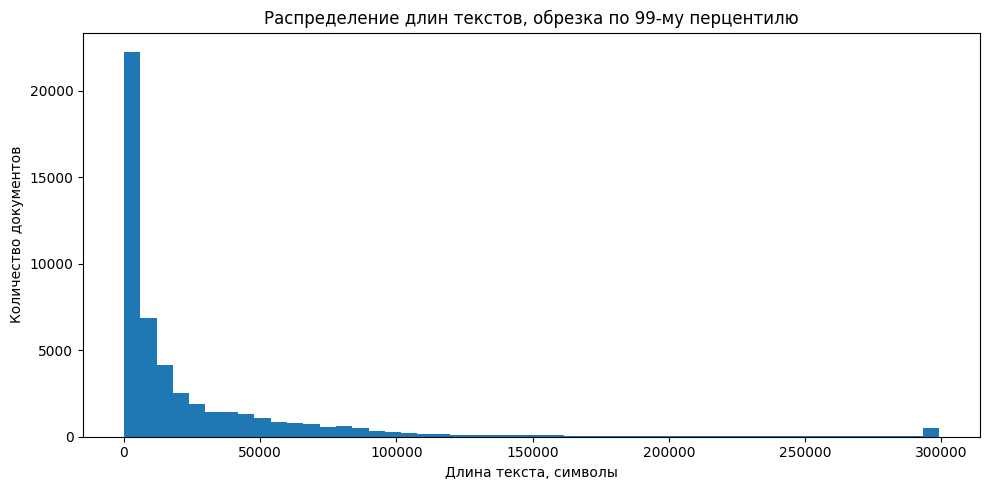

Число уникальных исходных кодов: 58


,code,count
0,010.000.000,17421
1,020.000.000,6501
2,010.150.000,4695
3,250.000.000,2158
4,210.000.000,2125
5,160.000.000,1939
6,220.000.000,1190
7,120.000.000,1111
8,020.020.000,1069
9,010.160.030,949


In [4]:
text_lengths = df[TEXT_COL].dropna().astype(str).str.len()

print("Длина текстов:")
print(f"Средняя длина: {text_lengths.mean():.1f}")
print(f"Медианная длина: {text_lengths.median():.1f}")
print(f"Минимальная длина: {text_lengths.min():,}")
print(f"Максимальная длина: {text_lengths.max():,}")

plt.figure(figsize=(10, 5))
plt.hist(text_lengths.clip(upper=text_lengths.quantile(0.99)), bins=50)
plt.title("Распределение длин текстов, обрезка по 99-му перцентилю")
plt.xlabel("Длина текста, символы")
plt.ylabel("Количество документов")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "text_length_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

target_counts_raw = df[TARGET_COL].astype(str).value_counts()
print(f"Число уникальных исходных кодов: {target_counts_raw.shape[0]:,}")
display(target_counts_raw.head(20).rename_axis("code").reset_index(name="count"))


## 4. Подготовка текста и удаление точных дубликатов

In [5]:
def normalize_text(text) -> str:
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_for_duplicate_check(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


work_df = df[[TEXT_COL, TARGET_COL]].copy()
work_df["text"] = work_df[TEXT_COL].apply(normalize_text)
work_df["target_raw"] = work_df[TARGET_COL].apply(normalize_text)

work_df = work_df[(work_df["text"].str.len() > 0) & (work_df["target_raw"].str.len() > 0)].reset_index(drop=True)
print(f"После удаления пустых текстов и целей: {len(work_df):,} строк")

work_df["text_norm_for_dups"] = work_df["text"].apply(normalize_for_duplicate_check)
duplicate_text_count = int(work_df.duplicated("text_norm_for_dups").sum())
duplicate_pair_count = int(work_df.duplicated(["text_norm_for_dups", "target_raw"]).sum())

print(f"Дубликатов текста без учета класса: {duplicate_text_count:,}")
print(f"Дубликатов пары текст+класс: {duplicate_pair_count:,}")

before = len(work_df)
work_df = work_df.drop_duplicates(["text_norm_for_dups", "target_raw"]).reset_index(drop=True)
print(f"Удалено точных дубликатов текст+класс: {before - len(work_df):,}")
print(f"Осталось строк: {len(work_df):,}")


После удаления пустых текстов и целей: 50,002 строк
Дубликатов текста без учета класса: 5
Дубликатов пары текст+класс: 5
Удалено точных дубликатов текст+класс: 5
Осталось строк: 49,997


## 5. Иерархия целевого кода

Код документа имеет иерархическую структуру. Поэтому из исходного значения строятся четыре варианта целевой переменной: полный код, первый уровень, второй уровень и третий уровень. В итоговой модели используется полный код `target_full`, потому что он сохраняет максимальную детализацию и при этом остается пригодным для стратифицированного разбиения.


In [6]:
def normalize_code_value(value) -> str:
    value = str(value).strip()
    if re.fullmatch(r"\d+\.0", value):
        value = value[:-2]
    value = re.sub(r"\s+", "", value)
    return value


def split_code_to_levels(code: str):
    code = normalize_code_value(code)
    if not code or code.lower() in {"nan", "none", "null"}:
        return (np.nan, np.nan, np.nan, np.nan)

    parts = [p for p in re.split(r"[.\-_/\\:;]+", code) if p]
    if len(parts) >= 2:
        level_1 = parts[0]
        level_2 = ".".join(parts[:2])
        level_3 = ".".join(parts[:3]) if len(parts) >= 3 else level_2
        return (code, level_1, level_2, level_3)

    compact = re.sub(r"[^0-9A-Za-zА-Яа-яЁё]", "", code)
    if len(compact) == 0:
        return (code, np.nan, np.nan, np.nan)

    return (code, compact[:1], compact[:2], compact[:3])


levels = work_df["target_raw"].apply(split_code_to_levels).apply(pd.Series)
levels.columns = ["target_full", "target_level_1", "target_level_2", "target_level_3"]
work_df = pd.concat([work_df, levels], axis=1)

hierarchy_summary = []
for col in ["target_full", "target_level_1", "target_level_2", "target_level_3"]:
    counts = work_df[col].value_counts(dropna=True)
    hierarchy_summary.append({
        "level": col,
        "n_classes": int(counts.shape[0]),
        "min_count": int(counts.min()) if len(counts) else 0,
        "median_count": float(counts.median()) if len(counts) else 0.0,
        "max_count": int(counts.max()) if len(counts) else 0,
        "top_class_share": float(counts.iloc[0] / len(work_df)) if len(counts) else 0.0,
    })

hierarchy_summary_df = pd.DataFrame(hierarchy_summary)
display(hierarchy_summary_df)
hierarchy_summary_df.to_csv(OUTPUT_DIR / "target_hierarchy_summary.csv", index=False, encoding="utf-8-sig")

for col in ["target_full", "target_level_1", "target_level_2", "target_level_3"]:
    print(f"\n{col}")
    display(work_df[col].value_counts().head(15).rename_axis(col).reset_index(name="count"))


,level,n_classes,min_count,median_count,max_count,top_class_share
0,target_full,58,15,195.5,17416,0.348341
1,target_level_1,19,16,445.0,26581,0.531652
2,target_level_2,42,16,256.5,17416,0.348341
3,target_level_3,58,15,195.5,17416,0.348341



target_full


,target_full,count
0,010.000.000,17416
1,020.000.000,6501
2,010.150.000,4695
3,250.000.000,2158
4,210.000.000,2125
5,160.000.000,1939
6,220.000.000,1190
7,120.000.000,1111
8,020.020.000,1069
9,010.160.030,949



target_level_1


,target_level_1,count
0,010,26581
1,020,10268
2,210,3257
3,250,2395
4,160,2108
5,220,1190
6,120,1111
7,030,812
8,050,587
9,230,445



target_level_2


,target_level_2,count
0,010.000,17416
1,020.000,6501
2,010.150,5479
3,250.000,2158
4,210.000,2125
5,160.000,1939
6,020.020,1596
7,010.160,1516
8,220.000,1190
9,020.030,1143



target_level_3


,target_level_3,count
0,010.000.000,17416
1,020.000.000,6501
2,010.150.000,4695
3,250.000.000,2158
4,210.000.000,2125
5,160.000.000,1939
6,220.000.000,1190
7,120.000.000,1111
8,020.020.000,1069
9,010.160.030,949


Итоговый уровень целевой переменной: target_full
Удалено строк редких классов: 0
Удалено редких классов: 0
Размер выборки для моделирования: 49,997 строк
Число классов: 58
Доля крупнейшего класса: 34.83%


,target,count
0,010.000.000,17416
1,020.000.000,6501
2,010.150.000,4695
3,250.000.000,2158
4,210.000.000,2125
5,160.000.000,1939
6,220.000.000,1190
7,120.000.000,1111
8,020.020.000,1069
9,010.160.030,949


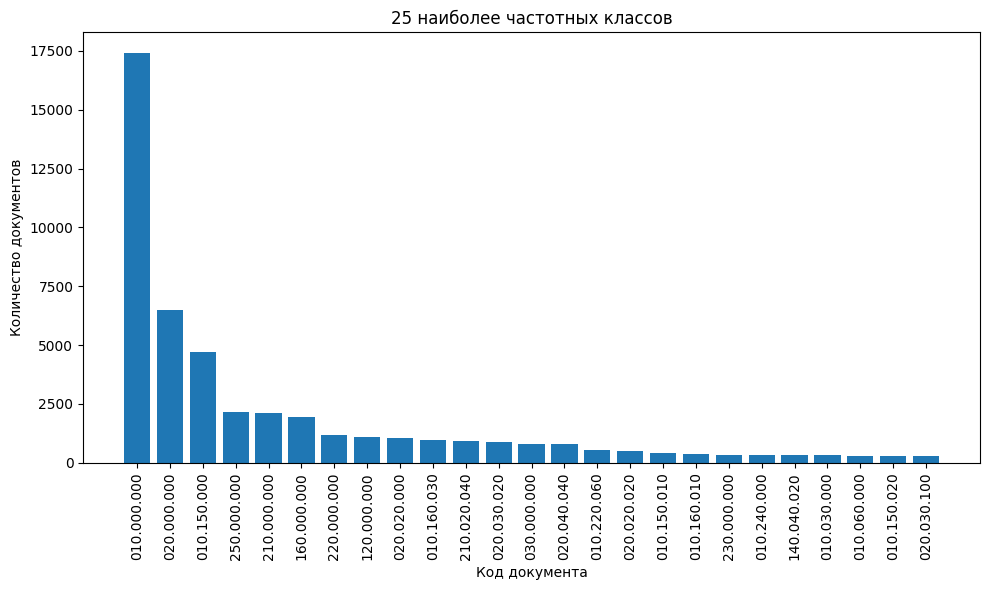

In [7]:
model_df = work_df[[
    "text",
    "text_norm_for_dups",
    "target_raw",
    "target_full",
    "target_level_1",
    "target_level_2",
    "target_level_3",
]].copy()

model_df["target"] = model_df[TARGET_LEVEL].astype(str)
model_df = model_df[~model_df["target"].isin(["", "nan", "None", "NaN"])].copy()

class_counts = model_df["target"].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index

removed_rare_rows = int((~model_df["target"].isin(valid_classes)).sum())
removed_rare_classes = int((class_counts < MIN_SAMPLES_PER_CLASS).sum())

model_df = model_df[model_df["target"].isin(valid_classes)].reset_index(drop=True)

print(f"Итоговый уровень целевой переменной: {TARGET_LEVEL}")
print(f"Удалено строк редких классов: {removed_rare_rows:,}")
print(f"Удалено редких классов: {removed_rare_classes:,}")
print(f"Размер выборки для моделирования: {len(model_df):,} строк")
print(f"Число классов: {model_df['target'].nunique():,}")
print(f"Доля крупнейшего класса: {model_df['target'].value_counts(normalize=True).iloc[0]:.2%}")

class_distribution = model_df["target"].value_counts().rename_axis("target").reset_index(name="count")
display(class_distribution.head(30))
class_distribution.to_csv(OUTPUT_DIR / "class_distribution_selected_target.csv", index=False, encoding="utf-8-sig")

plt.figure(figsize=(10, 6))
plt.bar(class_distribution["target"].head(25), class_distribution["count"].head(25))
plt.title("25 наиболее частотных классов")
plt.xlabel("Код документа")
plt.ylabel("Количество документов")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "target_distribution_top_classes.png", dpi=160, bbox_inches="tight")
plt.show()


## 6. Разбиение на train и test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    model_df["text"],
    model_df["target"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=model_df["target"],
)

print(f"Train: {len(X_train):,}")
print(f"Test:  {len(X_test):,}")
print(f"Классов в train: {pd.Series(y_train).nunique():,}")
print(f"Классов в test:  {pd.Series(y_test).nunique():,}")

split_info = {
    "n_samples": int(len(model_df)),
    "n_classes": int(model_df["target"].nunique()),
    "test_size": TEST_SIZE,
    "target_level": TARGET_LEVEL,
    "text_col": TEXT_COL,
    "target_col": TARGET_COL,
}
(OUTPUT_DIR / "split_info.json").write_text(json.dumps(split_info, ensure_ascii=False, indent=2), encoding="utf-8")


Train: 39,997
Test:  10,000
Классов в train: 58
Классов в test:  58


142

## 7. Анализ TF-IDF-признаков и проверка возможных утечек

В задании важно не только обучить классификатор, но и проверить, не использует ли модель слишком прямые технические признаки. Поэтому ниже строятся TF-IDF-признаки и через критерий chi-square выбираются наиболее информативные слова и фрагменты. Для каждого признака дополнительно отмечается, похож ли он на дату, год, номер документа, технический код, административный маркер или часть целевого кода.


In [9]:
REGION_AND_ADMIN_MARKERS = {
    "москва", "московский", "московская", "санкт", "петербург", "петербурга",
    "татарстан", "башкортостан", "краснодар", "краснодарский", "пермский",
    "свердловская", "новосибирская", "нижегородская", "самарская", "ростовская",
    "челябинская", "иркутская", "омская", "томская", "тюменская",
    "край", "область", "республика", "муниципальный", "городской", "сельский",
    "поселение", "район", "округ", "администрация", "совет", "дума"
}


def build_target_token_set(values):
    tokens = set()
    for value in pd.Series(values).dropna().astype(str).str.lower().unique():
        tokens.add(value)
        for part in re.split(r"[.\-_/\\:;\s]+", value):
            if len(part) >= 2:
                tokens.add(part)
    return tokens


def suspicious_feature_reason(term: str, target_tokens: set):
    term = str(term).lower().strip()
    reasons = []

    if re.search(r"\d", term):
        reasons.append("contains_digit")
    if re.fullmatch(r"(?:19|20)\d{2}", term):
        reasons.append("year")
    if re.search(r"\b\d{1,2}[./-]\d{1,2}[./-]\d{2,4}\b", term):
        reasons.append("date")
    if re.fullmatch(r"[a-zа-яё]*\d+[a-zа-яё]*", term):
        reasons.append("code_like_token")
    if len(term) <= 3 and re.search(r"\d", term):
        reasons.append("short_numeric_code")
    if term in REGION_AND_ADMIN_MARKERS:
        reasons.append("region_or_admin_marker")
    if term in target_tokens:
        reasons.append("equals_or_part_of_target_code")
    if re.search(r"(?:№|\bn\b|\bno\b)", term):
        reasons.append("document_number_marker")

    return ", ".join(reasons)


analysis_vectorizer = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[\w\-/.№]+\b",
    ngram_range=WORD_NGRAM_RANGE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=120_000,
    sublinear_tf=True,
)

X_train_tfidf = analysis_vectorizer.fit_transform(X_train)
feature_names = np.array(analysis_vectorizer.get_feature_names_out())

chi2_scores, p_values = chi2(X_train_tfidf, y_train)
feature_scores = pd.DataFrame({
    "feature": feature_names,
    "chi2": chi2_scores,
    "p_value": p_values,
}).sort_values("chi2", ascending=False)

target_tokens = build_target_token_set(y_train)
feature_scores["suspicious_reason"] = feature_scores["feature"].apply(
    lambda term: suspicious_feature_reason(term, target_tokens)
)
feature_scores["is_suspicious"] = feature_scores["suspicious_reason"].str.len() > 0

print("ТОП-30 TF-IDF-признаков по chi-square:")
display(feature_scores.head(30))

suspicious_features = feature_scores[feature_scores["is_suspicious"]].head(50)
print("ТОП-50 потенциально подозрительных признаков:")
display(suspicious_features)

suspicious_share_top500 = float(feature_scores.head(TOP_N_FEATURES_TO_SAVE)["is_suspicious"].mean())
print(f"Доля потенциально подозрительных признаков среди ТОП-{TOP_N_FEATURES_TO_SAVE}: {suspicious_share_top500:.2%}")

feature_scores.head(TOP_N_FEATURES_TO_SAVE).to_csv(
    OUTPUT_DIR / "tfidf_chi2_top_features.csv", index=False, encoding="utf-8-sig"
)
suspicious_features.to_csv(
    OUTPUT_DIR / "tfidf_suspicious_features.csv", index=False, encoding="utf-8-sig"
)


ТОП-30 TF-IDF-признаков по chi-square:


,feature,chi2,p_value,suspicious_reason,is_suspicious
104837,спорта находящихся,3818.054322,0.000000e+00,,False
53832,испытывающих потребность,3365.503903,0.000000e+00,,False
43171,древесине для,3070.653391,0.000000e+00,,False
30757,в древесине,2691.517622,0.000000e+00,,False
43170,древесине,2604.612353,0.000000e+00,,False
72471,объектов спорта,2358.269808,0.000000e+00,,False
102587,собрания российской,2327.050130,0.000000e+00,,False
38020,граждан испытывающих,2239.700151,0.000000e+00,,False
114972,федерального собрания,2198.313040,0.000000e+00,,False
72297,объекта спорта,2187.602344,0.000000e+00,,False


ТОП-50 потенциально подозрительных признаков:


,feature,chi2,p_value,suspicious_reason,is_suspicious
14209,26.01.2026,1681.675331,0.000000e+00,"contains_digit, date",True
68613,ноября 2000,1616.915361,1.283078e-300,contains_digit,True
14210,26.01.2026 текст,1580.707026,5.019441e-293,"contains_digit, date",True
14499,28.01.2026 текст,1299.723334,2.406376e-234,"contains_digit, date",True
14498,28.01.2026,1299.001351,3.400280e-234,"contains_digit, date",True
14024,25.01.2026 текст,1255.955464,2.999122e-225,"contains_digit, date",True
14023,25.01.2026,1254.133955,7.165145e-225,"contains_digit, date",True
27793,аналитический 0,1061.797030,4.324646e-185,contains_digit,True
14633,29.01.2026,1036.276442,7.721404e-180,"contains_digit, date",True
14634,29.01.2026 текст,1027.589417,4.717640e-178,"contains_digit, date",True


Доля потенциально подозрительных признаков среди ТОП-500: 14.40%


In [10]:
def normalize_for_direct_match(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"\s+", "", text)
    return text


direct_check_df = pd.DataFrame({"text": X_train, "target": y_train}).copy()
direct_check_df["text_norm"] = direct_check_df["text"].apply(normalize_for_direct_match)
direct_check_df["target_norm"] = direct_check_df["target"].apply(normalize_for_direct_match)

direct_check_df["target_code_in_text"] = False
mask = direct_check_df["target_norm"].str.len() >= 3
direct_check_df.loc[mask, "target_code_in_text"] = [
    target in text
    for target, text in zip(direct_check_df.loc[mask, "target_norm"], direct_check_df.loc[mask, "text_norm"])
]

direct_leakage_rate = float(direct_check_df["target_code_in_text"].mean())
print(f"Доля train-документов, где целевой код напрямую встречается в тексте: {direct_leakage_rate:.2%}")

direct_examples = direct_check_df[direct_check_df["target_code_in_text"]].head(20)[["target", "text"]]
display(direct_examples)
direct_examples.to_csv(
    OUTPUT_DIR / "direct_target_code_in_text_examples.csv", index=False, encoding="utf-8-sig"
)


Доля train-документов, где целевой код напрямую встречается в тексте: 0.00%


,target,text
44966,010.000.000,"ПОСТАНОВЛЕНИЕ от 28.11.2025 № 2217 Администрация муниципального образования ""Кабанский район"" 19.01.2026 Текст документа ﻿ Телефонограмма АДМИНИСТРАЦИЯ МУНИЦИПАЛЬНОГО ОБРАЗОВАН..."


## 8. Очистка текста от технических маркеров

In [11]:
def clean_text_from_technical_markers(text: str) -> str:
    text = str(text)

    # Номера документов: № 123, N 123-ОЗ, No 45/2021 и похожие варианты.
    text = re.sub(
        r"(?:№|\bN\b|\bNo\b|\bNо\b)\s*[A-Za-zА-Яа-яЁё0-9_./\-]+",
        " НОМЕР_ДОКУМЕНТА ",
        text,
        flags=re.IGNORECASE,
    )

    # Даты.
    text = re.sub(r"\b\d{1,2}[./-]\d{1,2}[./-]\d{2,4}\b", " ДАТА ", text)
    text = re.sub(r"\b\d{4}[./-]\d{1,2}[./-]\d{1,2}\b", " ДАТА ", text)

    # Годы.
    text = re.sub(r"\b(?:19|20)\d{2}\b", " ГОД ", text)

    # Длинные числовые последовательности и технические коды.
    text = re.sub(r"\b\d{3,}\b", " ЧИСЛОВОЙ_КОД ", text)
    text = re.sub(
        r"\b[А-ЯA-Z]{1,6}-?\d{2,}[А-ЯA-Z0-9\-/]*\b",
        " ТЕХНИЧЕСКИЙ_КОД ",
        text,
        flags=re.IGNORECASE,
    )

    text = re.sub(r"\s+", " ", text).strip()
    return text


X_train_clean = X_train.apply(clean_text_from_technical_markers)
X_test_clean = X_test.apply(clean_text_from_technical_markers)

print("Пример до очистки:")
print(X_train.iloc[0][:1000])

print("\nПример после очистки:")
print(X_train_clean.iloc[0][:1000])


Пример до очистки:
РЕШЕНИЕ от 30.04.2025 № 143 Совет Александровского сельского поселения Бавлинского муниципального района Республики Татарстан 20.01.2026 Текст документа ﻿ проект 1 СОВЕТ АЛЕКСАНДРОВСКОГО СЕЛЬСКОГО ПОСЕЛЕНИЯ БАВЛИНСКОГО МУНИЦИПАЛЬНОГО РАЙОНА РЕСПУБЛИКИ ТАТАРСТАН ТАТАРСТАН РЕСПУБЛИКАСЫ БАУЛЫ МУНИЦИПАЛЬ РАЙОНЫ АЛЕКСАНДРОВКА АВЫЛ Җ ИРЛЕГЕ СОВЕТЫ РЕШЕНИЕ КАРАР 30.04.2025 с . Алекс андровк а № 143 О внесении изменений в решение Совета Александровского сельского поселения от 1 1.04 .2018 № 59 « О нормативах формирования расходов на оплату труда выборных должностных лиц местного самоуправления, осуществляющих свои полномочия на постоянной основе, муниципальных служащих органов местного самоуправления Александровского сельского поселения Бавлинского муниципального района Республики Татарстан» В соответствии с постановлением Кабинета Министров Республики Татарстан от 14.04.2025 № 228 «О внесении изменений в постановление Кабинета Министров Республики Татарстан от 28.03.2018 №1

## 9. Обучение моделей

Для сравнения используются несколько моделей:

`DummyClassifier` — базовый уровень, показывающий качество простого угадывания самого частого класса.  
`word_tfidf_linear_svc` — TF-IDF по словам и линейный SVM.  
`char_tfidf_linear_svc` — TF-IDF по символьным n-граммам и линейный SVM.  
`word_char_tfidf_linear_svc` — объединение словесных и символьных TF-IDF-признаков.  
`word_tfidf_sgd_logloss` — линейная модель через SGD с логистической функцией потерь.

Основная метрика — `macro F1`, так как классы распределены неравномерно, а качество на редких классах также важно.


In [12]:
def make_word_tfidf():
    return TfidfVectorizer(
        lowercase=True,
        token_pattern=r"(?u)\b\w\w+\b",
        ngram_range=WORD_NGRAM_RANGE,
        min_df=MIN_DF,
        max_df=MAX_DF,
        max_features=WORD_MAX_FEATURES,
        sublinear_tf=True,
        norm="l2",
    )


def make_char_tfidf():
    return TfidfVectorizer(
        analyzer="char_wb",
        lowercase=True,
        ngram_range=CHAR_NGRAM_RANGE,
        min_df=MIN_DF,
        max_df=MAX_DF,
        max_features=CHAR_MAX_FEATURES,
        sublinear_tf=True,
        norm="l2",
    )


def make_word_char_features():
    return FeatureUnion([
        ("word", make_word_tfidf()),
        ("char", make_char_tfidf()),
    ], n_jobs=-1)


def make_linear_svc():
    return LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=5000,
    )


models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),

    "word_tfidf_linear_svc": Pipeline([
        ("features", make_word_tfidf()),
        ("clf", make_linear_svc()),
    ]),

    "char_tfidf_linear_svc": Pipeline([
        ("features", make_char_tfidf()),
        ("clf", make_linear_svc()),
    ]),

    "word_char_tfidf_linear_svc": Pipeline([
        ("features", make_word_char_features()),
        ("clf", make_linear_svc()),
    ]),

    "word_tfidf_sgd_logloss": Pipeline([
        ("features", make_word_tfidf()),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=1e-5,
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}

print("Модели для сравнения:")
for model_name in models:
    print("-", model_name)


Модели для сравнения:
- dummy_most_frequent
- word_tfidf_linear_svc
- char_tfidf_linear_svc
- word_char_tfidf_linear_svc
- word_tfidf_sgd_logloss


In [13]:
def top_k_accuracy_from_estimator(model, X, y_true, k=5):
    try:
        classes = np.asarray(model.classes_)
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X)
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X)
        else:
            return np.nan

        if scores.ndim == 1:
            scores = np.vstack([-scores, scores]).T

        k = min(k, scores.shape[1])
        top_indices = np.argpartition(scores, -k, axis=1)[:, -k:]
        top_labels = classes[top_indices]

        return float(np.mean([true_label in predicted_labels for true_label, predicted_labels in zip(y_true, top_labels)]))
    except Exception:
        return np.nan


def evaluate_model(model_name, estimator, X_tr, y_tr, X_te, y_te):
    start_time = time.time()

    estimator.fit(X_tr, y_tr)
    fit_time = time.time() - start_time

    y_pred = estimator.predict(X_te)

    metrics = {
        "model": model_name,
        "fit_time_sec": fit_time,
        "accuracy": accuracy_score(y_te, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_te, y_pred),
        "precision_macro": precision_score(y_te, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_te, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_te, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_te, y_pred, average="weighted", zero_division=0),
        "top_3_accuracy": top_k_accuracy_from_estimator(estimator, X_te, y_te, k=3),
        "top_5_accuracy": top_k_accuracy_from_estimator(estimator, X_te, y_te, k=5),
    }

    return estimator, y_pred, metrics


results = []
fitted_models = {}
predictions = {}

for model_name, model in models.items():
    print(f"\nОбучение модели: {model_name}")
    fitted_model, y_pred, model_metrics = evaluate_model(
        model_name, model, X_train, y_train, X_test, y_test
    )

    fitted_models[model_name] = fitted_model
    predictions[model_name] = y_pred
    results.append(model_metrics)

    print(pd.Series(model_metrics))

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv(OUTPUT_DIR / "model_metrics_raw_text.csv", index=False, encoding="utf-8-sig")



Обучение модели: dummy_most_frequent
model                dummy_most_frequent
fit_time_sec                    0.020529
accuracy                          0.3483
balanced_accuracy               0.017241
precision_macro                 0.006005
recall_macro                    0.017241
f1_macro                        0.008908
f1_weighted                     0.179949
top_3_accuracy                    0.3559
top_5_accuracy                    0.3595
dtype: object

Обучение модели: word_tfidf_linear_svc
model                word_tfidf_linear_svc
fit_time_sec                     206.45218
accuracy                            0.8509
balanced_accuracy                 0.801236
precision_macro                   0.726971
recall_macro                      0.801236
f1_macro                          0.757053
f1_weighted                       0.853456
top_3_accuracy                       0.977
top_5_accuracy                      0.9889
dtype: object

Обучение модели: char_tfidf_linear_svc
model         

,model,fit_time_sec,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top_3_accuracy,top_5_accuracy
0,word_char_tfidf_linear_svc,1106.467283,0.8708,0.805370,0.766042,0.805370,0.780471,0.872335,0.9794,0.9896
1,word_tfidf_linear_svc,206.452180,0.8509,0.801236,0.726971,0.801236,0.757053,0.853456,0.9770,0.9889
2,char_tfidf_linear_svc,1069.425743,0.8291,0.810252,0.687805,0.810252,0.736875,0.833175,0.9697,0.9851
3,word_tfidf_sgd_logloss,148.406090,0.7488,0.806588,0.635790,0.806588,0.697586,0.754454,0.9488,0.9785
4,dummy_most_frequent,0.020529,0.3483,0.017241,0.006005,0.017241,0.008908,0.179949,0.3559,0.3595


## 10. Контрольная модель на очищенном тексте

In [14]:
clean_model = Pipeline([
    ("features", make_word_char_features()),
    ("clf", make_linear_svc()),
])

print("Обучение модели на очищенном тексте...")
clean_model, clean_pred, clean_metrics = evaluate_model(
    "word_char_tfidf_linear_svc_clean_text",
    clean_model,
    X_train_clean,
    y_train,
    X_test_clean,
    y_test,
)

clean_metrics_df = pd.DataFrame([clean_metrics])
display(clean_metrics_df)
clean_metrics_df.to_csv(OUTPUT_DIR / "model_metrics_clean_text.csv", index=False, encoding="utf-8-sig")

comparison_df = (
    pd.concat([results_df, clean_metrics_df], ignore_index=True)
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
display(comparison_df)
comparison_df.to_csv(OUTPUT_DIR / "model_metrics_comparison.csv", index=False, encoding="utf-8-sig")


Обучение модели на очищенном тексте...


,model,fit_time_sec,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top_3_accuracy,top_5_accuracy
0,word_char_tfidf_linear_svc_clean_text,1086.041654,0.7788,0.777686,0.676256,0.777686,0.717137,0.782671,0.9386,0.9634


,model,fit_time_sec,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top_3_accuracy,top_5_accuracy
0,word_char_tfidf_linear_svc,1106.467283,0.8708,0.805370,0.766042,0.805370,0.780471,0.872335,0.9794,0.9896
1,word_tfidf_linear_svc,206.452180,0.8509,0.801236,0.726971,0.801236,0.757053,0.853456,0.9770,0.9889
2,char_tfidf_linear_svc,1069.425743,0.8291,0.810252,0.687805,0.810252,0.736875,0.833175,0.9697,0.9851
3,word_char_tfidf_linear_svc_clean_text,1086.041654,0.7788,0.777686,0.676256,0.777686,0.717137,0.782671,0.9386,0.9634
4,word_tfidf_sgd_logloss,148.406090,0.7488,0.806588,0.635790,0.806588,0.697586,0.754454,0.9488,0.9785
5,dummy_most_frequent,0.020529,0.3483,0.017241,0.006005,0.017241,0.008908,0.179949,0.3559,0.3595


## 11. Подробный отчет по лучшей модели

In [15]:
best_model_name = str(results_df.iloc[0]["model"])
best_model = fitted_models[best_model_name]
best_pred = predictions[best_model_name]

print(f"Лучшая модель по macro F1: {best_model_name}")

report_dict = classification_report(y_test, best_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "class"})
display(report_df.head(30))
report_df.to_csv(OUTPUT_DIR / "classification_report_best_model.csv", index=False, encoding="utf-8-sig")

predictions_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "target_true": pd.Series(y_test).reset_index(drop=True),
    "target_pred": pd.Series(best_pred).reset_index(drop=True),
})
predictions_df["is_correct"] = predictions_df["target_true"] == predictions_df["target_pred"]
predictions_df["text_preview"] = predictions_df["text"].str[:500]

display(predictions_df.head(20))
predictions_df.to_csv(OUTPUT_DIR / "test_predictions_best_model.csv", index=False, encoding="utf-8-sig")

joblib.dump(best_model, OUTPUT_DIR / "best_model.joblib")
print(f"Лучшая модель сохранена: {OUTPUT_DIR / 'best_model.joblib'}")


Лучшая модель по macro F1: word_char_tfidf_linear_svc


,class,precision,recall,f1-score,support
0,010.000.000,0.963832,0.872237,0.915750,3483.0
1,010.020.000,0.571429,0.500000,0.533333,8.0
2,010.030.000,0.880597,0.921875,0.900763,64.0
3,010.030.050,0.750000,1.000000,0.857143,3.0
4,010.060.000,0.823529,0.736842,0.777778,57.0
5,010.070.000,0.727273,0.727273,0.727273,11.0
6,010.090.000,0.647059,0.687500,0.666667,16.0
7,010.140.020,0.800000,0.800000,0.800000,15.0
8,010.150.000,0.913886,0.904153,0.908994,939.0
9,010.150.010,0.843750,0.658537,0.739726,82.0


,text,target_true,target_pred,is_correct,text_preview
0,РЕШЕНИЕ от 12.11.2025 № 3 Сход граждан 19.01.2026 Текст документа ﻿ Решение схода граждан в селе Кзыл-Тау Кзыл-Тауского сельского поселения Апастовского муниципального района Р...,010.000.000,010.000.000,True,РЕШЕНИЕ от 12.11.2025 № 3 Сход граждан 19.01.2026 Текст документа ﻿ Решение схода граждан в селе Кзыл-Тау Кзыл-Тауского сельского поселения Апастовского муниципального района Р...
1,ПОСТАНОВЛЕНИЕ от 20.02.2025 № 150 Администрация муниципального района Белокатайский район Республики Башкортостан 23.01.2026 Текст документа ﻿ Администраци я муниципального рай...,020.000.000,020.000.000,True,ПОСТАНОВЛЕНИЕ от 20.02.2025 № 150 Администрация муниципального района Белокатайский район Республики Башкортостан 23.01.2026 Текст документа ﻿ Администраци я муниципального рай...
2,ПРИКАЗ от 14.11.2025 № 78-ос Аппарат Совета министров Республики Крым 24.01.2026 Текст документа ﻿ РЕСПУБЛИКА КРЫМ АППАРАТ СОВЕТА МИНИСТРА ПРИКАЗ от 14.11.2025 № 78-ос О КОМИСС...,020.020.020,020.020.020,True,ПРИКАЗ от 14.11.2025 № 78-ос Аппарат Совета министров Республики Крым 24.01.2026 Текст документа ﻿ РЕСПУБЛИКА КРЫМ АППАРАТ СОВЕТА МИНИСТРА ПРИКАЗ от 14.11.2025 № 78-ос О КОМИСС...
3,ПОСТАНОВЛЕНИЕ от 07.08.2025 № 43-п Администрация Тесинского сельсовета Минусинского района Красноярского края 20.01.2026 Текст документа ﻿ АДМИНИСТРАЦИЯ ТЕСИНСКОГО СЕЛЬСОВЕТА М...,010.000.000,010.000.000,True,ПОСТАНОВЛЕНИЕ от 07.08.2025 № 43-п Администрация Тесинского сельсовета Минусинского района Красноярского края 20.01.2026 Текст документа ﻿ АДМИНИСТРАЦИЯ ТЕСИНСКОГО СЕЛЬСОВЕТА М...
4,МУНИЦИПАЛЬНЫЙ ПРАВОВОЙ АКТ О ВНЕСЕНИИ ИЗМЕНЕНИЙ В УСТАВ МО от 28.03.2025 № 16-41-7 Собрание депутатов Знаменского сельсовета Щигровского района Курской области 20.01.2026 Текст...,010.000.000,010.000.000,True,МУНИЦИПАЛЬНЫЙ ПРАВОВОЙ АКТ О ВНЕСЕНИИ ИЗМЕНЕНИЙ В УСТАВ МО от 28.03.2025 № 16-41-7 Собрание депутатов Знаменского сельсовета Щигровского района Курской области 20.01.2026 Текст...
5,ПОСТАНОВЛЕНИЕ от 04.08.2025 № 39 администрация Упорниковского сельского поселения 01.02.2026 Текст документа ﻿ Начальнику управления финансов 1 АДМИНИСТРАЦИЯ УПОРНИКОВСКОГО СЕЛ...,250.000.000,250.000.000,True,ПОСТАНОВЛЕНИЕ от 04.08.2025 № 39 администрация Упорниковского сельского поселения 01.02.2026 Текст документа ﻿ Начальнику управления финансов 1 АДМИНИСТРАЦИЯ УПОРНИКОВСКОГО СЕЛ...
6,"ПОСТАНОВЛЕНИЕ от 19.05.2025 № 1227 Администрация муниципального образования ""Рославльский муниципальный округ"" Смоленской области 20.01.2026 Текст документа ﻿ АДМИНИСТРАЦИЯ МУН...",010.000.000,010.000.000,True,"ПОСТАНОВЛЕНИЕ от 19.05.2025 № 1227 Администрация муниципального образования ""Рославльский муниципальный округ"" Смоленской области 20.01.2026 Текст документа ﻿ АДМИНИСТРАЦИЯ МУН..."
7,РЕШЕНИЕ от 25.07.2025 № 2-20/4 Комитет местного самоуправления Раевского сельсовета Земетчинского района Пензенской области 22.01.2026 Текст документа ﻿ КОМИТЕТ МЕСТНОГО САМОУП...,020.000.000,020.000.000,True,РЕШЕНИЕ от 25.07.2025 № 2-20/4 Комитет местного самоуправления Раевского сельсовета Земетчинского района Пензенской области 22.01.2026 Текст документа ﻿ КОМИТЕТ МЕСТНОГО САМОУП...
8,ПОСТАНОВЛЕНИЕ от 05.12.2025 № 203 глава Жирновского муниципального района 28.01.2026 Текст документа ﻿ ГЛАВЫ ЖИРНОВСКОГО МУНИЦИПАЛЬНОГО РАЙОНА ВОЛГОГРАДСКОЙ ОБЛАСТИ П О С Т А Н...,120.000.000,120.000.000,True,ПОСТАНОВЛЕНИЕ от 05.12.2025 № 203 глава Жирновского муниципального района 28.01.2026 Текст документа ﻿ ГЛАВЫ ЖИРНОВСКОГО МУНИЦИПАЛЬНОГО РАЙОНА ВОЛГОГРАДСКОЙ ОБЛАСТИ П О С Т А Н...
9,ПОСТАНОВЛЕНИЕ от 16.10.2025 № 668 Администрация Терновского муниципального района Воронежской области 19.01.2026 Текст документа ﻿ АДМИНИСТРАЦИЯ ТЕРНОВСКОГО МУНИЦИПАЛЬНОГО РАЙО...,010.000.000,010.000.000,True,ПОСТАНОВЛЕНИЕ от 16.10.2025 № 668 Администрация Терновского муниципального района Воронежской области 19.01.2026 Текст документа ﻿ АДМИНИСТРАЦИЯ ТЕРНОВСКОГО МУНИЦИПАЛЬНОГО РАЙО...


Лучшая модель сохранена: task2_outputs_final\best_model.joblib


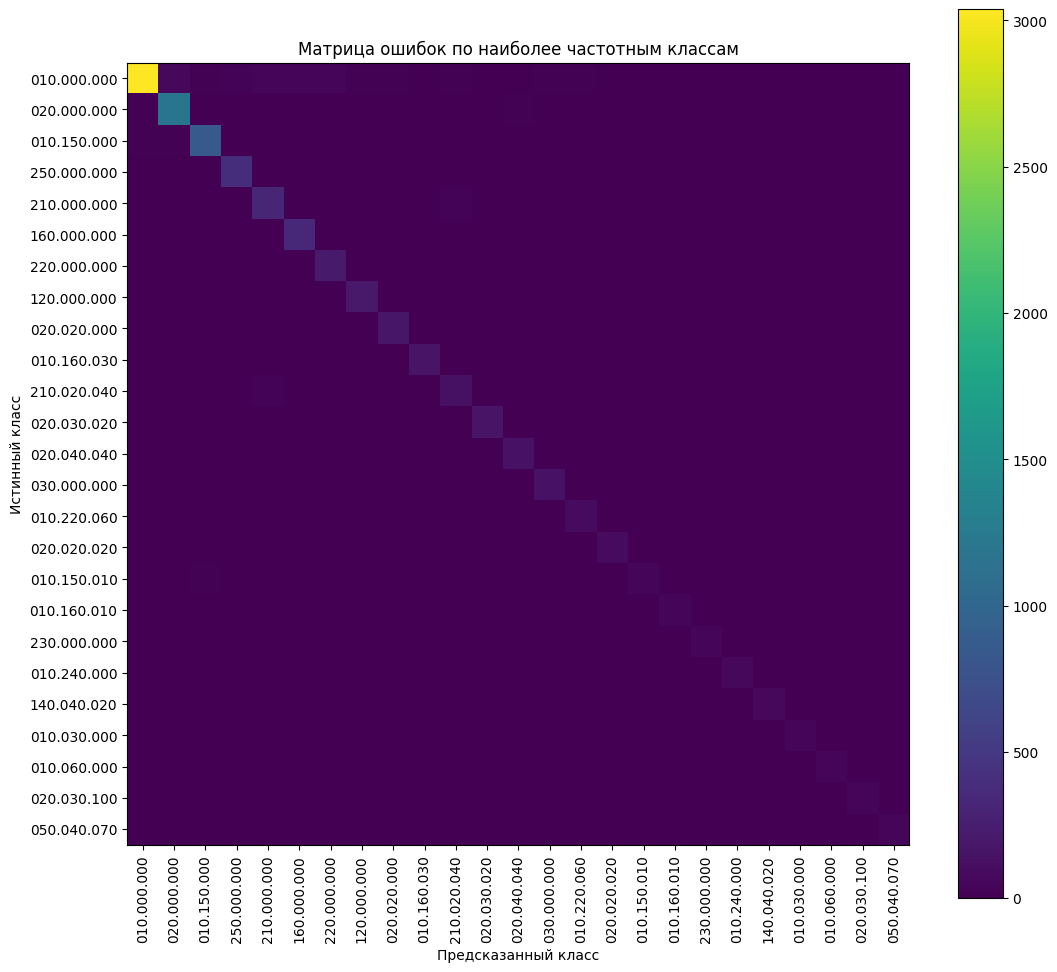

In [16]:
top_classes = (
    pd.Series(y_test)
    .value_counts()
    .head(min(TOP_N_CLASSES_FOR_PLOTS, pd.Series(y_test).nunique()))
    .index
    .tolist()
)

y_test_series = pd.Series(y_test).reset_index(drop=True)
best_pred_series = pd.Series(best_pred).reset_index(drop=True)
top_mask = y_test_series.isin(top_classes).values

cm = confusion_matrix(y_test_series[top_mask], best_pred_series[top_mask], labels=top_classes)

plt.figure(figsize=(max(8, len(top_classes) * 0.45), max(6, len(top_classes) * 0.40)))
plt.imshow(cm, interpolation="nearest")
plt.title("Матрица ошибок по наиболее частотным классам")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(range(len(top_classes)), top_classes, rotation=90)
plt.yticks(range(len(top_classes)), top_classes)
plt.colorbar()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_top_classes.png", dpi=160, bbox_inches="tight")
plt.show()


## 12. Анализ ошибок

In [17]:
errors_df = predictions_df[~predictions_df["is_correct"]].copy()

print(f"Ошибок на тесте: {len(errors_df):,} из {len(predictions_df):,}")

common_confusions = (
    errors_df.groupby(["target_true", "target_pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Наиболее частые пары ошибок:")
display(common_confusions.head(30))
common_confusions.to_csv(OUTPUT_DIR / "common_confusions.csv", index=False, encoding="utf-8-sig")

print("Примеры ошибок:")
error_examples = errors_df[["target_true", "target_pred", "text_preview"]].head(TOP_N_ERROR_EXAMPLES)
display(error_examples)
error_examples.to_csv(OUTPUT_DIR / "error_examples.csv", index=False, encoding="utf-8-sig")

per_class_report = report_df[~report_df["class"].isin(["accuracy", "macro avg", "weighted avg"])].copy()
per_class_report["support"] = per_class_report["support"].astype(float)

worst_classes = (
    per_class_report[per_class_report["support"] > 0]
    .sort_values(["f1-score", "support"])
    .head(30)
)

print("Классы с худшим F1:")
display(worst_classes)
worst_classes.to_csv(OUTPUT_DIR / "worst_classes_by_f1.csv", index=False, encoding="utf-8-sig")


Ошибок на тесте: 1,292 из 10,000
Наиболее частые пары ошибок:


,target_true,target_pred,count
17,010.000.000,020.000.000,64
32,010.000.000,210.000.000,46
30,010.000.000,160.000.000,41
35,010.000.000,220.000.000,39
293,210.000.000,210.020.040,35
314,210.020.040,210.000.000,27
38,010.000.000,250.000.000,24
59,010.150.000,010.000.000,23
28,010.000.000,120.000.000,22
155,020.000.000,010.000.000,20


Примеры ошибок:


,target_true,target_pred,text_preview
13,020.030.100,020.020.020,ПОСТАНОВЛЕНИЕ от 20.06.2025 № 345 Правительство Удмуртской Республики 24.01.2026 Текст документа ﻿ ПРАВИТЕЛЬСТВО УДМУРТСКОЙ РЕСПУБЛИКИ ПОСТАНОВЛЕНИЕ от 20 июня 2025 года № 345 ...
17,010.000.000,010.060.000,РЕШЕНИЕ от 20.11.2025 № 142 Совет депутатов Мечетненского муниципального образования 19.01.2026 Текст документа ﻿ МЕЧЕТНЕНСКОЕ МУНИЦИПАЛЬНОЕ ОБРАЗОВАНИЕ СОВЕТСКОГО МУНИЦИПАЛЬНО...
22,020.000.000,020.020.000,ПОСТАНОВЛЕНИЕ от 08.12.2025 № 119-п Администрация Тюхтетского муниципального округа Красноярского края 22.01.2026 Текст документа ﻿ Дата фактической утраты силы 01.01.202 7 в с...
29,210.000.000,210.020.040,ПОСТАНОВЛЕНИЕ от 15.04.2025 № 444 Администрация Бежаницкого муниципального округа 31.01.2026 Текст документа ﻿ Документ подписан электронно-цифровой подписью: Владелец: АДМИНИС...
42,010.000.000,210.000.000,РЕШЕНИЕ от 11.04.2025 № 133/101 Собрание представителей сельского поселения Натальино муниципального района Безенчукский Самарской области 20.01.2026 Текст документа ﻿ Федераль...
46,010.000.000,010.160.030,ПОСТАНОВЛЕНИЕ от 05.08.2025 № 446 Администрация муниципального округа муниципальное образование Антрацитовский муниципальный округ Луганской Народной Республики 20.01.2026 Текс...
67,010.000.000,020.020.000,ПОСТАНОВЛЕНИЕ от 05.08.2025 № 53-п Администрация Говорковского сельсовета Богучанского района Красноярского края 20.01.2026 Текст документа ﻿ Администрация Говорковского сельсо...
70,210.000.000,160.000.000,РЕШЕНИЕ от 29.05.2025 № 30/187 Собрание депутатов поселка Медвенка Медвенского района Курской области 31.01.2026 Текст документа ﻿ АДМИНИСТРАЦИЯ ГОРОДА КУРСКА СОБРАНИЕ ДЕПУТАТО...
82,010.150.000,010.150.050,РЕШЕНИЕ от 01.09.2025 № 144 Собрание депутатов Нижнеборковского сельсовета Горшеченского района Курской области 21.01.2026 Текст документа ﻿ СОБРАНИЕ ДЕПУТАТОВ НИЖНЕБОРКОВСКОГО...
94,210.000.000,010.000.000,ПОСТАНОВЛЕНИЕ от 12.11.2025 № 6374 Администрация города Мурманска 30.01.2026 Текст документа ﻿ Документ подписан электронно-цифровой подписью: Владелец: Лебедев Иван Николаевич...


Классы с худшим F1:


,class,precision,recall,f1-score,support
38,160.010.050,0.666667,0.352941,0.461538,17.0
44,210.010.010,0.500000,0.545455,0.521739,11.0
1,010.020.000,0.571429,0.500000,0.533333,8.0
22,020.020.110,0.571429,0.500000,0.533333,8.0
27,020.040.050,0.500000,0.647059,0.564103,17.0
39,160.010.070,0.523810,0.647059,0.578947,17.0
52,250.080.000,0.526316,0.689655,0.597015,29.0
13,010.160.020,0.605263,0.638889,0.621622,36.0
33,070.020.000,0.666667,0.666667,0.666667,3.0
32,060.050.000,0.583333,0.777778,0.666667,9.0


## 13. Итоговые выводы

После подготовки данных для моделирования осталось **49 997 документов**. В качестве текстовой колонки использовалась колонка `text`, в качестве исходной целевой переменной — `code`. Целевая переменная была рассмотрена как иерархический код: `target_full`, `target_level_1`, `target_level_2`, `target_level_3`. Для итоговой классификации выбран уровень `target_full`, так как на нем получилось **58 классов** и при этом сохраняется максимальная детализация задачи.

Лучший результат показала модель **`word_char_tfidf_linear_svc`**, то есть LinearSVC на объединении словесных и символьных TF-IDF-признаков. На тестовой выборке модель получила следующие значения метрик:

| Модель | Accuracy | Balanced accuracy | Macro F1 | Weighted F1 | Top-3 accuracy | Top-5 accuracy |
|---|---:|---:|---:|---:|---:|---:|
| word_char_tfidf_linear_svc | 0.8708 | 0.8054 | 0.7805 | 0.8723 | 0.9794 | 0.9896 |
| word_tfidf_linear_svc | 0.8509 | 0.8012 | 0.7571 | 0.8535 | 0.9770 | 0.9889 |
| char_tfidf_linear_svc | 0.8291 | 0.8103 | 0.7369 | 0.8332 | 0.9697 | 0.9851 |
| word_tfidf_sgd_logloss | 0.7488 | 0.8066 | 0.6976 | 0.7545 | 0.9488 | 0.9785 |
| dummy_most_frequent | 0.3483 | 0.0172 | 0.0089 | 0.1799 | 0.3559 | 0.3595 |

По сравнению с dummy baseline качество значительно выше, поэтому модель действительно извлекает информативные признаки из текста, а не просто повторяет самый частый класс. Основной метрикой выбрана `macro F1`, потому что классы распределены неравномерно и важно учитывать качество на редких кодах.

Проверка утечек показала, что прямого присутствия целевого кода в тексте практически нет: доля таких случаев в train-части составила **0.00%**. Однако среди 500 наиболее информативных TF-IDF-признаков около **14.40%** были отмечены как потенциально подозрительные: это даты, годы, номера документов, технические коды и административные маркеры. После очистки текста от таких элементов качество модели снизилось с **macro F1 = 0.7805** до **macro F1 = 0.7171**. Следовательно, технические признаки помогают модели, но не являются единственным источником качества: модель также использует содержательные формулировки нормативно-правовых актов.

Основные ошибки возникают между близкими или слишком общими кодами, например между `010.000.000` и `020.000.000`, `010.000.000` и `210.000.000`, а также между `210.000.000` и `210.020.040`. Это ожидаемо для иерархической классификации: модель чаще путает близкие или пересекающиеся по формулировкам разделы.

Итог: для данного датасета TF-IDF + LinearSVC является сильным и интерпретируемым baseline. Для дальнейшего улучшения можно использовать group split по региону, муниципалитету или источнику, если такая колонка доступна, а также попробовать иерархическую классификацию: сначала предсказывать крупный раздел кода, затем уточняющий уровень.


## 14. Краткое объяснение решения

Задача была решена как мультиклассовая классификация текстов нормативно-правовых актов по коду документа. Сначала был проведен разведочный анализ: проверены пропуски, дубликаты, длины текстов и распределение целевого кода. Затем целевой код был разложен на уровни иерархии, но для финального обучения выбран полный код `target_full`, потому что он сохраняет детализацию и остается пригодным для обучения.

Для представления текстов использовался TF-IDF. Были сравнены словесные n-граммы, символьные n-граммы и их объединение. Лучший результат дала модель LinearSVC на объединенных word+char TF-IDF-признаках. Такой результат логичен: словесные признаки отражают содержательные формулировки документов, а символьные n-граммы лучше учитывают словоформы, сокращения, реквизиты и устойчивые фрагменты юридического текста.

Отдельно была выполнена проверка возможных утечек. Для этого были изучены наиболее информативные TF-IDF-признаки, проверено прямое присутствие целевого кода в тексте и проведен контрольный эксперимент на очищенном тексте. Падение качества после очистки оказалось умеренным, поэтому технические признаки действительно помогают классификации, но не объясняют результат полностью.


In [18]:
summary = {
    "final_dataset_rows": 49_997,
    "target_level": "target_full",
    "n_classes": 58,
    "best_model": "word_char_tfidf_linear_svc",
    "best_accuracy": 0.8708,
    "best_macro_f1": 0.7805,
    "best_weighted_f1": 0.8723,
    "clean_text_macro_f1": 0.7171,
    "direct_target_code_in_text_rate": 0.0,
    "suspicious_features_share_top500": 0.1440,
}

(OUTPUT_DIR / "final_summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("Итоговый summary сохранен.")


Итоговый summary сохранен.
